# Method success statistics for major events export
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

## Introduction
Or - what does this method exactly do?

write it neatly here

### Current problems and onward

write it neatly here

## Setup

### Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [2]:
current_dir = sys.path[0] # directory path of the notebook
main_dir = os.path.dirname(current_dir) # directory path of the main repository folder

### Link function notebook

In [3]:
# Adding path to system
sys.path.append(main_dir)

In [4]:
# Importing relevant functions
from functions import get_len, get_count, get_area, get_density, wrap_api_query # API call requests
from functions import get_add_from_cum, semi_norm_mix_transform # Method functions
from functions import generate_measure_sample_plot # plotting functions

### Current working method (with log)

In [5]:
# Assess the feature completness measure of some polygon using cumulative feature counts and lengths/areas
def assess_feature_completeness(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

            stable['count_change'] = stable['count'] / stable['count'].max() # Calculate absolute change
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    print('Data incomplete: no stable absolute addition period')
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

## Data setup (EDA)

### Import extracted data from Ohsome API

In [6]:
# Import building data
bld_areas = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_areas.csv")
bld_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_counts.csv")

In [7]:
# Import road data
road_lengths = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_lengths.csv")
road_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_counts.csv")

In [8]:
# Import events metadata (percentage + bbox)
samp = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

### Assess completeness using method

In [9]:
# Assess feature completeness for buildings
bld_tests = []

for idx, count_group in bld_counts.groupby('idx'):
    area_group = bld_areas[bld_areas['idx'] == idx].copy() # grouping area dataframe entries
    
    res = assess_feature_completeness(count_group, area_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    bld_tests.append(res)

In [10]:
# Assess feature completeness for roads
road_tests = []

for idx, count_group in road_counts.groupby('idx'):
    len_group = road_lengths[road_lengths['idx'] == idx].copy() # grouping length dataframe entries
    
    res = assess_feature_completeness(count_group, len_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    road_tests.append(res)

## Panel checks

* No. of complete
* No. of incomplete
* Percentages of each incompletion type

### Building data

In [11]:
bld_status = sum(1 for entry in bld_tests if entry.get('status') == 'complete') # general completeness status for buildings

In [12]:
bld_complete_percentage = round(bld_status / len(bld_tests) * 100, 3) # completeness percentage for buildings

In [13]:
# Completeness status for buildings by event type
bld_complete_by_type = {}
bld_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    bld_complete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    bld_incomplete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [14]:
# Calculate complete and incomplete counts and percentages for buildings by event type
bld_status_by_type = pd.DataFrame(bld_complete_by_type.items(), columns=['Event type', 'Complete'])
bld_status_by_type['Incomplete'] = bld_status_by_type['Event type'].map(bld_incomplete_by_type)
bld_status_by_type['Sample size (n)'] = bld_status_by_type['Complete'] + bld_status_by_type['Incomplete']
bld_status_by_type['Complete percentage'] = round(bld_status_by_type['Complete'] / bld_status_by_type['Sample size (n)'], 3)
bld_status_by_type['Incomplete percentage'] = round(1 - bld_status_by_type['Complete percentage'], 3)

In [15]:
print("Results:")
print(f"Overall completeness for buildings: {bld_status} out of {len(bld_tests)} events ({bld_complete_percentage}%)")
display(Markdown(bld_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for buildings: 76 out of 446 events (17.04%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          4 |           24 |                28 |                 0.143 |                   0.857 |
| remote_event    |         43 |          216 |               259 |                 0.166 |                   0.834 |
| early_import    |         24 |          103 |               127 |                 0.189 |                   0.811 |
| geometry_import |          1 |            7 |                 8 |                 0.125 |                   0.875 |
| tag_import      |          4 |            5 |                 9 |                 0.444 |                   0.556 |
| late_import     |          0 |           15 |                15 |                 0     |                   1     |

### Road data

In [16]:
road_status = sum(1 for entry in road_tests if entry.get('status') == 'complete') # general completeness status for roads

In [17]:
road_complete_percentage = round(road_status / len(road_tests) * 100, 3) # completeness percentage for roads

In [18]:
# Completeness status for roads by event type
road_complete_by_type = {}
road_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    road_complete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    road_incomplete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [19]:
# Calculate complete and incomplete counts and percentages for buildings by event type
road_status_by_type = pd.DataFrame(road_complete_by_type.items(), columns=['Event type', 'Complete'])
road_status_by_type['Incomplete'] = road_status_by_type['Event type'].map(road_incomplete_by_type)
road_status_by_type['Sample size (n)'] = road_status_by_type['Complete'] + road_status_by_type['Incomplete']
road_status_by_type['Complete percentage'] = round(road_status_by_type['Complete'] / road_status_by_type['Sample size (n)'], 3)
road_status_by_type['Incomplete percentage'] = round(1 - road_status_by_type['Complete percentage'], 3)

In [20]:
print("Results:")
print(f"Overall completeness for roads: {road_status} out of {len(road_tests)} events ({road_complete_percentage}%)")
display(Markdown(road_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for roads: 35 out of 446 events (7.848%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          1 |           27 |                28 |                 0.036 |                   0.964 |
| remote_event    |         22 |          237 |               259 |                 0.085 |                   0.915 |
| early_import    |         11 |          116 |               127 |                 0.087 |                   0.913 |
| geometry_import |          0 |            8 |                 8 |                 0     |                   1     |
| tag_import      |          0 |            9 |                 9 |                 0     |                   1     |
| late_import     |          1 |           14 |                15 |                 0.067 |                   0.933 |

## Distributions

### Pre-processing

#### Possible Incompletion Reasons:
1. **`no stable period`**: The growth rate at the end of the timeline exceeds the allowed alpha.
2. **`stable period shorter than threshold`**: The period of stability does not meet the minimum year requirement.
3. **`stable absolute addition larger than threshold`**: Significant absolute growth occurred after a major addition event.
4. **`stable relative addition larger than threshold`**: The relative change from the saturation point to the end of the data is too high.

In [21]:
# Add incompletion reason per each event (building data)
bld_status_by_type['No stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
bld_status_by_type['Small stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
bld_status_by_type['Stable absolute addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
bld_status_by_type['Stable relative addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [40]:
# Add incompletion reason per each event (road data)
road_status_by_type['No stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
road_status_by_type['Small stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
road_status_by_type['Stable absolute addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
road_status_by_type['Stable relative addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [ ]:
# reason list and label map for easier data map
reasons = ['No stable period', 'Small stable period', 'Stable absolute addition', 'Stable relative addition'] # list for easier mapping
label_map = {
    'local_knowledge': 'Local Knowledge',
    'remote_event': 'Remote Event',
    'early_import': 'Early Import',
    'geometry_import': 'Geometry Import',
    'tag_import': 'Tag Import',
    'late_import': 'Late Import'
}

### Completion Saturation Distributions

In [27]:
# Extract saturation dates for complete entries
saturation_data = []

# Process building data
for entry in bld_tests:
    if entry.get('status') == 'complete':
        saturation_data.append({
            'idx': entry.get('idx'),
            'event_type': entry.get('event_type'),
            'saturation_point': entry.get('saturation_point'),
            'dataset': 'Buildings'
        })

# Process road data
for entry in road_tests:
    if entry.get('status') == 'complete':
        saturation_data.append({
            'idx': entry.get('idx'),
            'event_type': entry.get('event_type'),
            'saturation_point': entry.get('saturation_point'),
            'dataset': 'Roads'
        })

# Create dataframe
saturation_df = pd.DataFrame(saturation_data)

# Separate by dataset
bld_sat = saturation_df[saturation_df['dataset'] == 'Buildings'].sort_values('saturation_point').reset_index(drop=True)
road_sat = saturation_df[saturation_df['dataset'] == 'Roads'].sort_values('saturation_point').reset_index(drop=True)

C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\3689687879.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bld_months = bld_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\3689687879.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bld_years = bld_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\3689687879.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


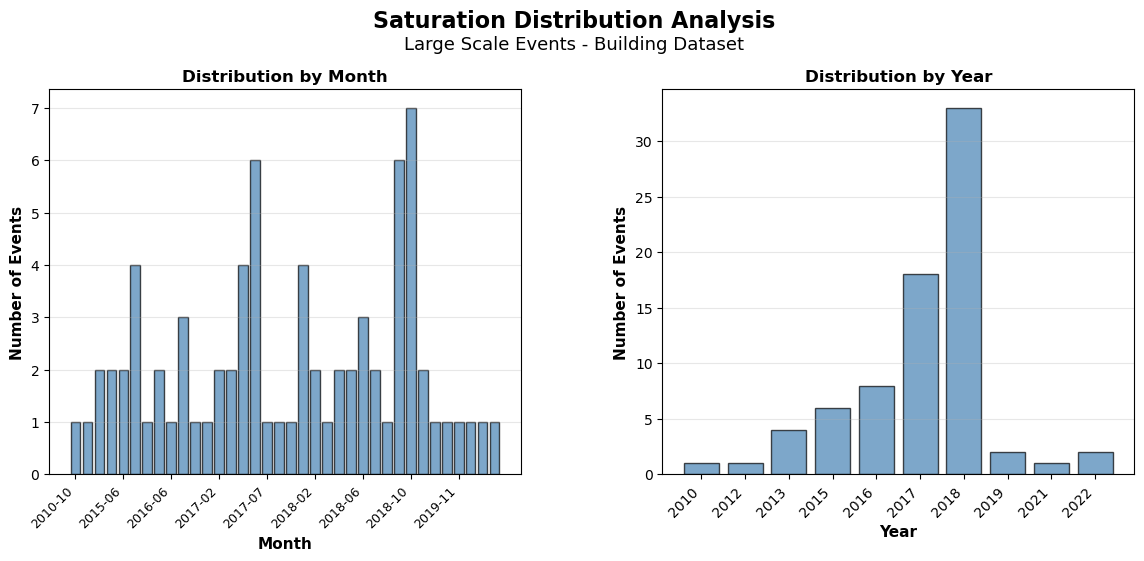

Building Events (Complete):
  Total: 76
  Earliest saturation: 2010-10-01
  Latest saturation: 2022-12-01


In [37]:
# ===== BUILDINGS BLOCK =====
fig1 = plt.figure(figsize=(14, 5))
gs1 = gridspec.GridSpec(1, 2, figure=fig1, hspace=0.3, wspace=0.3)

ax1_month = fig1.add_subplot(gs1[0, 0])
ax1_year = fig1.add_subplot(gs1[0, 1])

# Left: Histogram by month for buildings
bld_months = bld_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
bld_months_str = bld_months.index.astype(str)
ax1_month.bar(range(len(bld_months)), bld_months.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1_month.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1_month.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax1_month.set_title('Distribution by Month', fontsize=12, fontweight='bold')
ax1_month.set_xticks(range(0, len(bld_months), max(1, len(bld_months) // 8)))
ax1_month.set_xticklabels(bld_months_str[::max(1, len(bld_months) // 8)], rotation=45, ha='right', fontsize=9)
ax1_month.grid(True, alpha=0.3, axis='y')

# Right: Histogram by year for buildings
bld_years = bld_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
bld_years_str = bld_years.index.astype(str)
ax1_year.bar(range(len(bld_years)), bld_years.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1_year.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1_year.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax1_year.set_title('Distribution by Year', fontsize=12, fontweight='bold')
ax1_year.set_xticks(range(len(bld_years)))
ax1_year.set_xticklabels(bld_years_str, rotation=45, ha='right')
ax1_year.grid(True, alpha=0.3, axis='y')

plt.suptitle('Saturation Distribution Analysis', fontsize=16, fontweight='bold', y=1.04)
fig1.text(0.5, 0.96, 'Large Scale Events - Building Dataset', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Building Events (Complete):")
print(f"  Total: {len(bld_sat)}")
print(f"  Earliest saturation: {bld_sat['saturation_point'].min().date()}")
print(f"  Latest saturation: {bld_sat['saturation_point'].max().date()}")

C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\425559372.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  road_months = road_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\425559372.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  road_years = road_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_10080\425559372.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


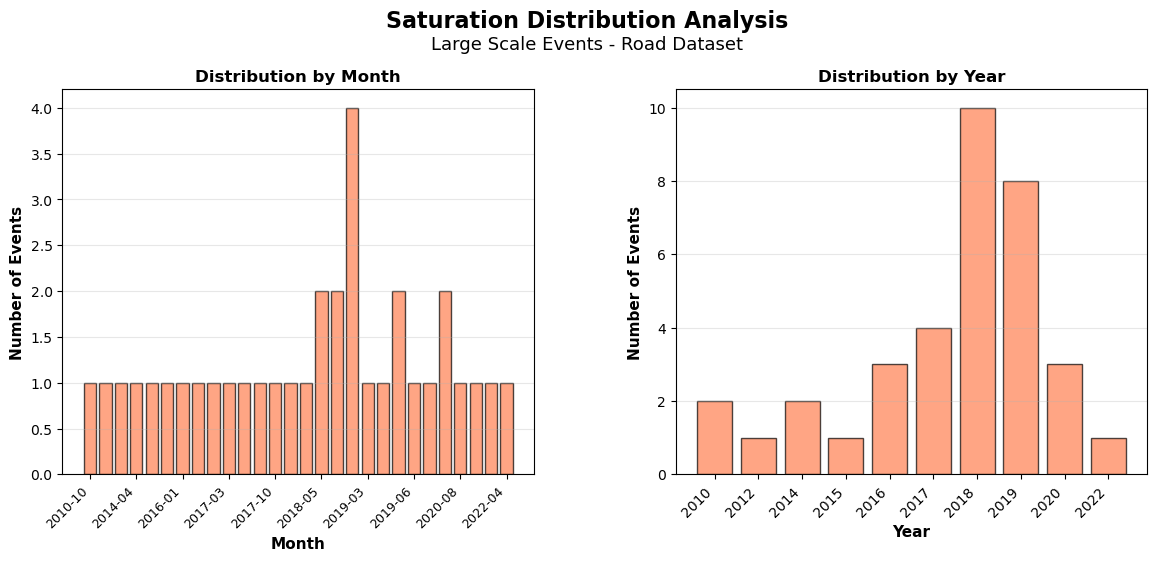


Road Events (Complete):
  Total: 35
  Earliest saturation: 2010-10-01
  Latest saturation: 2022-04-01


In [38]:
# ===== ROADS BLOCK =====
fig2 = plt.figure(figsize=(14, 5))
gs2 = gridspec.GridSpec(1, 2, figure=fig2, hspace=0.3, wspace=0.3)

ax2_month = fig2.add_subplot(gs2[0, 0])
ax2_year = fig2.add_subplot(gs2[0, 1])

# Left: Histogram by month for roads
road_months = road_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
road_months_str = road_months.index.astype(str)
ax2_month.bar(range(len(road_months)), road_months.values, color='coral', alpha=0.7, edgecolor='black')
ax2_month.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2_month.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax2_month.set_title('Distribution by Month', fontsize=12, fontweight='bold')
ax2_month.set_xticks(range(0, len(road_months), max(1, len(road_months) // 8)))
ax2_month.set_xticklabels(road_months_str[::max(1, len(road_months) // 8)], rotation=45, ha='right', fontsize=9)
ax2_month.grid(True, alpha=0.3, axis='y')

# Right: Histogram by year for roads
road_years = road_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
road_years_str = road_years.index.astype(str)
ax2_year.bar(range(len(road_years)), road_years.values, color='coral', alpha=0.7, edgecolor='black')
ax2_year.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2_year.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax2_year.set_title('Distribution by Year', fontsize=12, fontweight='bold')
ax2_year.set_xticks(range(len(road_years)))
ax2_year.set_xticklabels(road_years_str, rotation=45, ha='right')
ax2_year.grid(True, alpha=0.3, axis='y')

plt.suptitle('Saturation Distribution Analysis', fontsize=16, fontweight='bold', y=1.04)
fig2.text(0.5, 0.96, 'Large Scale Events - Road Dataset', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nRoad Events (Complete):")
print(f"  Total: {len(road_sat)}")
print(f"  Earliest saturation: {road_sat['saturation_point'].min().date()}")
print(f"  Latest saturation: {road_sat['saturation_point'].max().date()}")

### Incompletion Ratios by Reason

In [24]:
#  General bar plot of incompletion reasons by event dataset
bld_status_by_type_sum = bld_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all building dataset
road_status_by_type_sum = road_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all road dataset

# Calculate proportions
bld_status_by_type_sum[reasons] = round(bld_status_by_type_sum[reasons] / bld_status_by_type_sum['Incomplete'].iloc[0], 4)
road_status_by_type_sum[reasons] = round(road_status_by_type_sum[reasons] / road_status_by_type_sum['Incomplete'].iloc[0], 4)

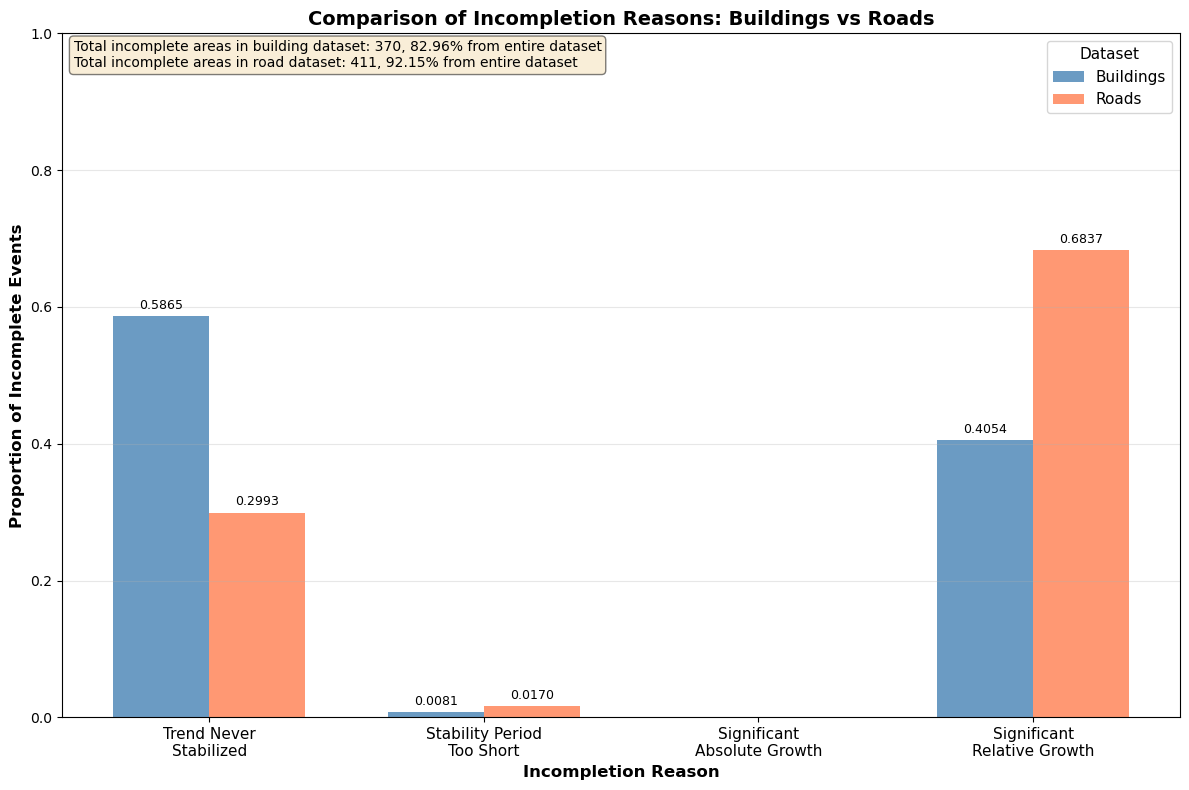

In [35]:
# Prepare data for plotting
bld_plot = bld_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
bld_plot['Data'] = 'Buildings'

road_plot = road_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
road_plot['Data'] = 'Roads'

# Combine and melt to long format
plot_data = pd.concat([bld_plot, road_plot], ignore_index=True)
plot_data = plot_data.melt(id_vars=['Data'], var_name='Reason', value_name='Proportion')

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique reasons and datasets
reasons_list = plot_data['Reason'].unique()
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(reasons_list))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_data[plot_data['Data'] == dataset]
    values = [data_subset[data_subset['Reason'] == reason]['Proportion'].values[0] if any(data_subset['Reason'] == reason) else 0 for reason in reasons_list]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Rename reasons for cleaner labels
reason_map = {
    'No stable period': 'Trend Never\nStabilized',
    'Stable relative addition': 'Significant\nRelative Growth',
    'Small stable period': 'Stability Period\nToo Short',
    'Stable absolute addition': 'Significant\nAbsolute Growth'
}

# Set labels and formatting
ax.set_xlabel('Incompletion Reason', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of Incomplete Events', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Incompletion Reasons: Buildings vs Roads', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels([reason_map.get(r, r) for r in reasons_list], fontsize=11)
ax.legend(title='Dataset', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add incompletion counts as text label in top left
bld_incomplete = bld_status_by_type_sum['Incomplete'].iloc[0]
road_incomplete = road_status_by_type_sum['Incomplete'].iloc[0]
incompletion_text = f'Total incomplete areas in building dataset: {int(bld_incomplete)}, {int(bld_incomplete) / 446 * 100:.2f}% from entire dataset\nTotal incomplete areas in road dataset: {int(road_incomplete)}, {int(road_incomplete) / 446 * 100:.2f}% from entire dataset'

ax.text(0.01, 0.99, incompletion_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

###  Incompletion ratios by event type

In [46]:
bld_status_by_type

,Event type,Complete,Incomplete,Sample size (n),Complete percentage,Incomplete percentage,No stable period,Small stable period,Stable absolute addition,Stable relative addition
0,local_knowledge,4,24,28,0.143,0.857,9,0,0,15
1,remote_event,43,216,259,0.166,0.834,131,2,0,83
2,early_import,24,103,127,0.189,0.811,63,1,0,39
3,geometry_import,1,7,8,0.125,0.875,4,0,0,3
4,tag_import,4,5,9,0.444,0.556,2,0,0,3
5,late_import,0,15,15,0.000,1.000,8,0,0,7


#### Event Type only

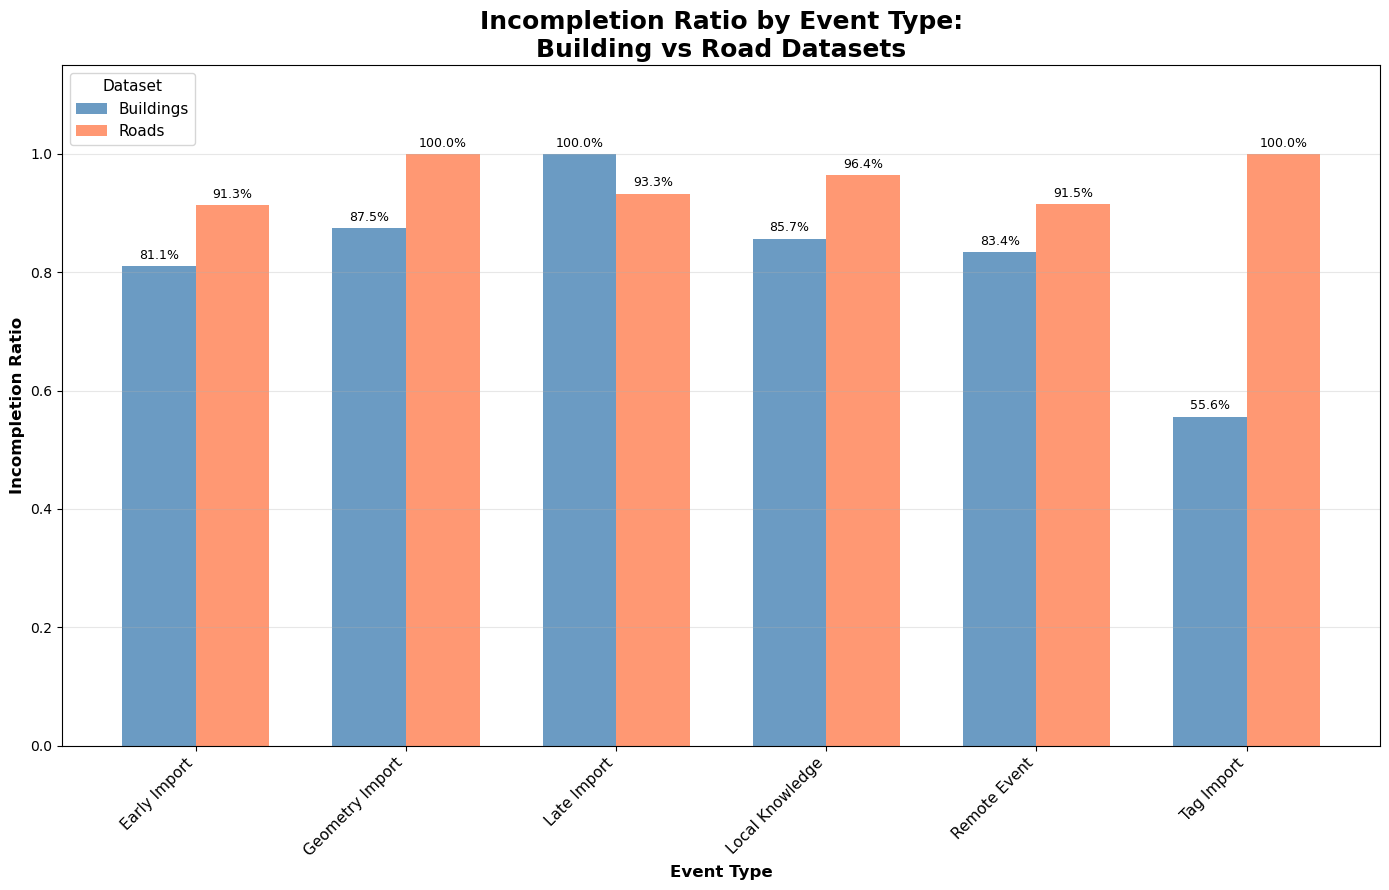

In [53]:
# Prepare data for plotting by event type
# Rename events for cleaner plot labels
bld_plot_data = bld_status_by_type.copy()
road_plot_data = road_status_by_type.copy()

bld_plot_data['Event type'] = bld_plot_data['Event type'].replace(label_map)
road_plot_data['Event type'] = road_plot_data['Event type'].replace(label_map)

# Create combined dataframe for plotting
plot_by_event = pd.concat([
    bld_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Buildings'),
    road_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(14, 9))

# Get unique event types
event_types = sorted(bld_plot_data['Event type'].unique())
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(event_types))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_by_event[plot_by_event['Dataset'] == dataset]
    values = [data_subset[data_subset['Event type'] == event]['Incomplete percentage'].values[0] if any(data_subset['Event type'] == event) else 0 for event in event_types]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Set labels and formatting
ax.set_xlabel('Event Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
ax.set_title('Incompletion Ratio by Event Type:\nBuilding vs Road Datasets', 
             fontsize=18, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(event_types, fontsize=11, rotation=45, ha='right')
ax.legend(title='Dataset', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Event Type & Reason

In [ ]:
# Format data in long format for plotting:

# Data extraction
bld_long = bld_status_by_type[['Event type', 'Incomplete'] + reasons].copy()
rds_long = road_status_by_type[['Event type', 'Incomplete'] + reasons].copy()

# Renaming events for cleaner plot labels
bld_long['Event type'] = bld_long['Event type'].replace(label_map)
rds_long['Event type'] = rds_long['Event type'].replace(label_map)

# Ensure matching columns for concatenation
rds_long.columns = bld_long.columns

# Normalize counts by reason to total incomplete data
bld_long[reasons] = bld_long[reasons].div(bld_long['Incomplete'], axis=0).fillna(0)
rds_long[reasons] = rds_long[reasons].div(rds_long['Incomplete'], axis=0).fillna(0)

# Add source labels
bld_long['Data'] = 'Buildings'
rds_long['Data'] = 'Roads'

# Concatenate data and convert to long format for plotting
combined = pd.concat([bld_long, rds_long], ignore_index=True)
combined = combined.melt(id_vars=['Event type', 'Data', 'Incomplete'], 
                        var_name='Reason', 
                        value_name='Proportion')

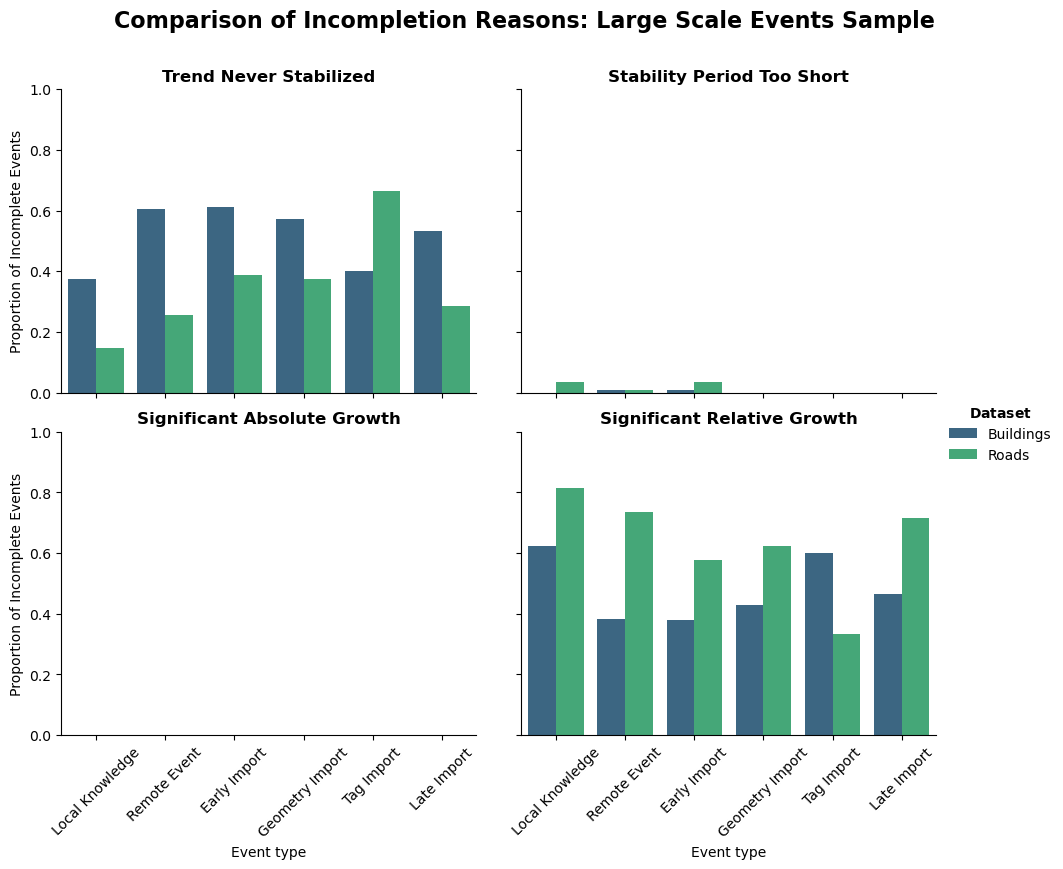

In [26]:
# Create a plot of the results
reason_map = {
    'No stable period': 'Trend Never Stabilized',
    'Small stable period': 'Stability Period Too Short',
    'Stable absolute addition': 'Significant Absolute Growth',
    'Stable relative addition': 'Significant Relative Growth'
}

g = sns.catplot(
    data=combined, 
    kind="bar",
    x="Event type", 
    y="Proportion",
    hue="Data",
    col="Reason",
    col_wrap=2,
    palette="viridis",
    height=4,
    aspect=1.2
)

g.set(ylim=(0, 1)) # Fix y axis limits to 0-100% for better comparison
g.set_titles(col_template="{col_name}", fontweight='bold') # Set column titles

# Set Y-axis to percentage format for clarity
for ax in g.axes.flat:
    # Get the current title
    current_title = ax.get_title().split('= ')[-1]
    # Map to new name and make bold
    new_title = reason_map.get(current_title, current_title)
    ax.set_title(new_title, fontweight='bold', fontsize=12)
    
    # Label the X-axis
    ax.tick_params(axis='x', labelrotation=45)
    
    # Label the Y-axis
    ax.set_ylabel("Proportion of Incomplete Events")

# Adjust legend title
g._legend.set_title(r"$\bf{Dataset}$")

# Add general title
plt.subplots_adjust(top=0.88) # Make room for the suptitle
g.fig.suptitle('Comparison of Incompletion Reasons: Large Scale Events Sample', 
               fontsize=16, fontweight='bold')

plt.show()

### By extent (bbox) size

#### Calculate area per each event polygon

In [85]:
# upload sample file for mask
events = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

In [86]:
# Re-read the geodataframe for crs conversion
gdf = gpd.read_file(r"H:\.shortcut-targets-by-id\1vC82Zl3hhtFy63TpICgdDiHqTHm5dv0h\OSM Projects\Data\Large-scale events\event_weights_grid.shp")

In [87]:
# Arrange data
gdf = gdf.rename(columns={
    'events_w_1' : 'local_knowledge',
    'events_w_2' : 'tag_import',
    'events_w_3' : 'remote_event',
    'events_w_4' : 'late_import',
    'events_w_5' : 'geometry_import',
    'events_w_6' : 'weight_sum',
    'events_wei' : 'early_import'
})

In [88]:
# Extract bounding box coordinates for mask
gdf[['minx', 'miny', 'maxx', 'maxy']] = gdf.bounds
gdf['bbox'] = gdf.apply(
    lambda row: f"{row['minx']},{row['miny']},{row['maxx']},{row['maxy']}",
    axis=1
)
gdf = gdf.drop(columns=['minx', 'miny', 'maxx', 'maxy']) # Drop intermediate columns

In [89]:
# Remove irrelevant columns that aren't in the sampled data
gdf = gdf[gdf['bbox'].isin(events['bbox'])]

In [90]:
gdf.to_crs(epsg=8857, inplace=True) # change crs to WGS84 / equal earth for accurate metric area calculation

In [91]:
gdf['area'] = gdf['geometry'].area # calculate area in square meters for each grid cell

#### Append to test data

In [105]:
# Create a string-keyed area lookup from gdf
area_lookup = {str(bbox): area for bbox, area in zip(gdf['bbox'], gdf['area'])}

# Apply rowwise lookup
bld_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in bld_tests]
road_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in road_tests]

In [112]:
road_tests[0].keys()

dict_keys(['result', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type', 'event_percentage', 'bbox', 'area'])

In [ ]:
sum(1 for entry in bld_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

In [115]:
road_status_by_area = pd.DataFrame(road_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()
bld_status_by_area = pd.DataFrame(bld_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()

In [116]:
road_status_by_area

,area,status,saturation_point,incompletion_reason,idx,event_type
0,7.199498e+08,incomplete,NaT,stable relative addition larger than threshold,0,local_knowledge
1,2.866106e+09,incomplete,NaT,stable period shorter than threshold,1,local_knowledge
2,6.868637e+08,incomplete,NaT,stable relative addition larger than threshold,2,local_knowledge
3,2.922787e+09,incomplete,NaT,stable relative addition larger than threshold,3,local_knowledge
4,2.872255e+09,incomplete,NaT,stable relative addition larger than threshold,4,local_knowledge
...,...,...,...,...,...,...
441,5.731140e+09,incomplete,NaT,stable relative addition larger than threshold,441,late_import
442,5.863445e+09,incomplete,NaT,stable relative addition larger than threshold,442,late_import
443,1.268142e+08,incomplete,NaT,no stable period,443,late_import
444,4.641579e+09,incomplete,NaT,stable relative addition larger than threshold,444,late_import


In [107]:
road_status_by_area

,area,Complete
0,local_knowledge,1
1,remote_event,22
2,early_import,11
3,geometry_import,0
4,tag_import,0
5,late_import,1
